# 02 - Regresión: Predicción de Consumo

**Pregunta de negocio:** ¿Podemos predecir el consumo por perfil de conductor?

## Objetivos
- Construir y comparar modelos de regresión para predecir el consumo medio de combustible
- Analizar qué características del vehículo y del conductor determinan el consumo
- Identificar el modelo más preciso y entender sus fortalezas/debilidades

## Teoría de Regresión

### Regresión Lineal y Supuestos
- **Linealidad**: relación lineal entre variables predictoras y la respuesta
- **Independencia**: las observaciones son independientes entre sí
- **Homocedasticidad**: la varianza de los residuos es constante
- **Normalidad de residuos**: los errores siguen una distribución normal
- Si estos supuestos se violan, las estimaciones de coeficientes pueden ser sesgadas

### Tradeoff Sesgo-Varianza
- **Sesgo alto** (underfitting): modelo demasiado simple, no captura patrones
- **Varianza alta** (overfitting): modelo demasiado complejo, se ajusta al ruido
- El punto óptimo minimiza el error total = sesgo² + varianza + ruido irreducible

### Regularización
- **Ridge (L2)**: penaliza la suma de coeficientes al cuadrado → encoge coeficientes pero no los elimina
- **Lasso (L1)**: penaliza la suma de valores absolutos → puede poner coeficientes a cero (selección de variables)
- El hiperparámetro `alpha` controla la fuerza de la penalización

### Métodos de Ensamble
- **Random Forest**: promedio de muchos árboles de decisión, cada uno entrenado con un subconjunto aleatorio de datos y features
- **XGBoost**: gradient boosting, construye árboles secuencialmente corrigiendo los errores del anterior

### Métricas de Evaluación
- **RMSE** (Root Mean Squared Error): en las mismas unidades que la variable, penaliza errores grandes
- **MAE** (Mean Absolute Error): en las mismas unidades, menos sensible a outliers
- **R²** (coeficiente de determinación): proporción de varianza explicada (1.0 = perfecto, 0 = inútil)

### Validación Cruzada
- Un solo split train/test puede dar resultados engañosos (depende de qué datos caen en cada conjunto)
- K-Fold CV divide los datos en K partes, entrena K veces usando K-1 partes y evalúa en la restante
- Nos da una estimación más robusta del rendimiento real del modelo

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, learning_curve
)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
    print("XGBoost disponible")
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost no instalado. Se omitirá ese modelo.")
    print("Para instalarlo: pip install xgboost")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

print(f"Raíz del proyecto: {project_root}")

XGBoost disponible
Raíz del proyecto: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos


## 1. Carga de Datos y Definición del Target

Cargamos `features_ml.csv` (generado por `01_feature_engineering`). Si no existe,
construimos las features básicas a partir de los datos crudos.

In [2]:
features_path = os.path.join(project_root, "data/processed/features_ml.csv")

if os.path.exists(features_path):
    print(f"Cargando features desde {features_path}")
    df = pd.read_csv(features_path)
else:
    print("features_ml.csv no encontrado. Construyendo features desde datos crudos...")
    
    # Cargar datos procesados (vehicle_survey_merged.csv)
    merged_path = os.path.join(project_root, "data/processed/vehicle_survey_merged.csv")
    if os.path.exists(merged_path):
        df = pd.read_csv(merged_path)
        print(f"  Cargado vehicle_survey_merged.csv: {df.shape}")
    else:
        # Cargar desde raw
        import glob as glob_mod
        raw_dir = os.path.join(project_root, "data/raw")
        fleet = pd.read_csv(os.path.join(raw_dir, "fleet_profiles.csv"))
        
        telemetry_files = sorted(glob_mod.glob(os.path.join(raw_dir, "telemetry/telemetry_*.csv")))
        telemetry = pd.concat([pd.read_csv(f) for f in telemetry_files], ignore_index=True)
        
        # Agregar por vehículo
        agg = telemetry.groupby('vehicle_id').agg(
            speed_mean=('speed_kmh', 'mean'),
            speed_max=('speed_kmh', 'max'),
            speed_std=('speed_kmh', 'std'),
            consumption_mean=('fuel_consumption_rate', 'mean'),
            consumption_total=('fuel_consumption_rate', 'sum'),
            n_registros=('speed_kmh', 'count'),
        ).reset_index()
        
        df = agg.merge(fleet, on='vehicle_id', how='left')
        
        # Cargar encuestas si existen
        survey_dir = os.path.join(raw_dir, "surveys")
        if os.path.exists(survey_dir):
            survey_files = sorted(glob_mod.glob(os.path.join(survey_dir, "*.csv")))
            if survey_files:
                surveys = pd.concat([pd.read_csv(f) for f in survey_files], ignore_index=True)
                df = df.merge(surveys, on='vehicle_id', how='left')
        
        print(f"  Construido desde datos crudos: {df.shape}")

print(f"\nDataset: {df.shape[0]} vehículos, {df.shape[1]} columnas")
df.head()

Cargando features desde /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/processed/features_ml.csv

Dataset: 50 vehículos, 26 columnas


,vehicle_id,avg_speed,speed_std,max_speed,avg_consumption,avg_battery_temp,battery_temp_std,total_trips,avg_trip_duration,total_estimated_km,...,vehicle_type_gasolina,vehicle_type_hibrido,purchase_reason_economia,purchase_reason_estilo,purchase_reason_rendimiento,purchase_reason_seguridad,purchase_reason_tecnologia,gender_masculino,expected_usage_ciudad,expected_usage_mixto
0,01cb4faa-246c-4ac4-967e-686646c718d0,60.440368,36.220028,123.89,10.993354,31.215629,6.746110,54,30.121296,1639.394619,...,0,0,1,0,0,0,0,1,0,1
1,05d940bb-0a44-4770-a2e0-465a8504b31e,53.890560,34.455347,123.21,5.405120,30.847021,6.269641,52,29.661859,1386.140064,...,0,1,0,0,1,0,0,0,1,0
2,0ec4f37e-68a2-4f11-b8d3-afa45ce8883e,54.152179,36.877091,130.00,8.108978,31.470978,6.601335,87,32.802874,2577.011958,...,0,1,0,0,1,0,0,1,1,0
3,0f83af6a-2312-4c76-9431-140c10b597c7,62.040321,37.000107,130.00,15.180791,32.782293,7.469872,84,33.242460,2888.769703,...,0,0,0,0,1,0,0,0,1,0
4,1b176ac7-e470-49a6-b1a5-b4c153f1f324,55.979026,36.352443,130.00,11.099477,31.445479,6.337474,72,31.198611,2096.881025,...,1,0,0,0,1,0,0,1,0,1


In [3]:
# Definir variable objetivo
target_col = None
for col_name in ['consumption_mean', 'avg_consumption']:
    if col_name in df.columns:
        target_col = col_name
        break

if target_col is None:
    raise ValueError("No se encontró la columna de consumo medio. "
                     f"Columnas disponibles: {list(df.columns)}")

print(f"Variable objetivo: {target_col}")
print(f"\nEstadísticas del target:")
print(df[target_col].describe())

Variable objetivo: avg_consumption

Estadísticas del target:
count    50.000000
mean     10.337057
std       5.235023
min       4.767787
25%       6.565210
50%       8.285026
75%      13.113817
max      25.202224
Name: avg_consumption, dtype: float64


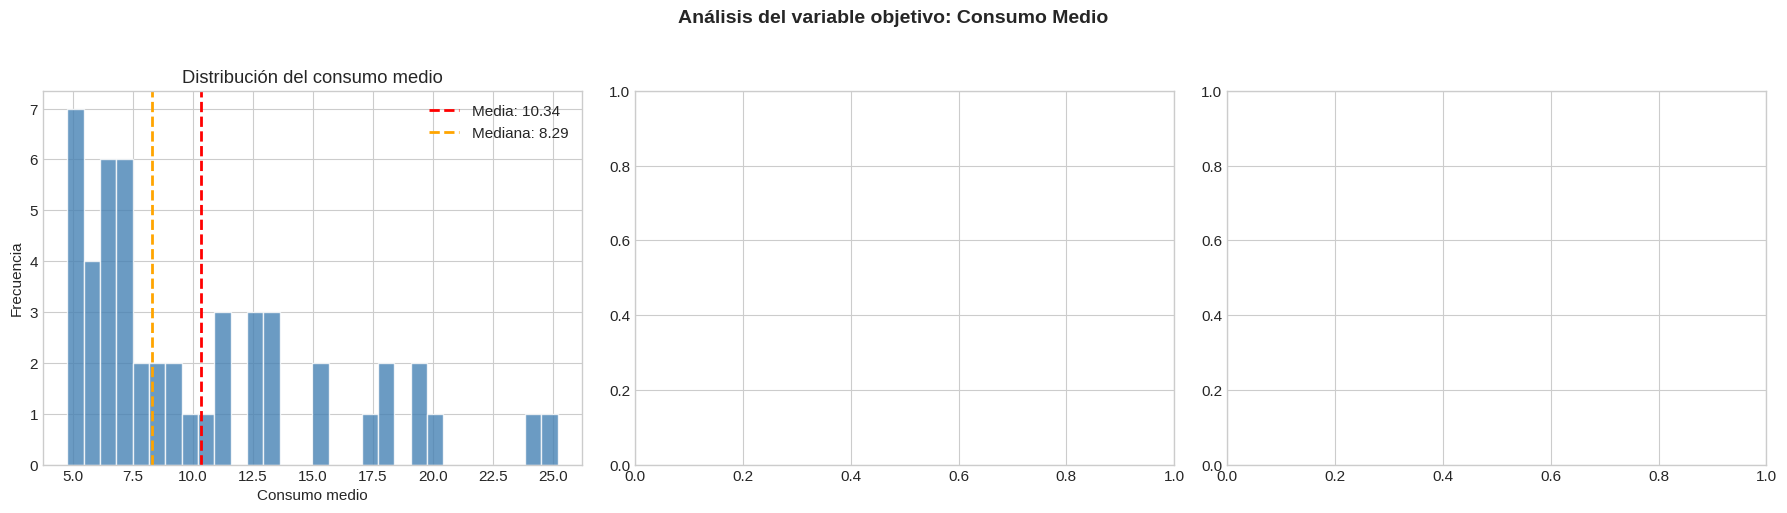


Skewness: 1.153
Kurtosis: 0.577


In [4]:
# Distribución del target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma general
axes[0].hist(df[target_col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[target_col].mean():.2f}')
axes[0].axvline(df[target_col].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df[target_col].median():.2f}')
axes[0].set_xlabel('Consumo medio')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del consumo medio')
axes[0].legend()

# Por tipo de vehículo
if 'vehicle_type' in df.columns:
    for vtype, color in vtype_colors.items():
        subset = df[df['vehicle_type'] == vtype][target_col].dropna()
        if len(subset) > 0:
            axes[1].hist(subset, bins=15, alpha=0.5, color=color, edgecolor='white', label=vtype.capitalize())
    axes[1].set_xlabel('Consumo medio')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución por tipo de vehículo')
    axes[1].legend()

# Box plot por tipo
if 'vehicle_type' in df.columns:
    vtypes_present = [v for v in vtype_colors if v in df['vehicle_type'].values]
    bp_data = [df[df['vehicle_type'] == v][target_col].dropna() for v in vtypes_present]
    bp = axes[2].boxplot(bp_data, labels=[v.capitalize() for v in vtypes_present], patch_artist=True)
    for patch, vtype in zip(bp['boxes'], vtypes_present):
        patch.set_facecolor(vtype_colors[vtype])
        patch.set_alpha(0.7)
    axes[2].set_ylabel('Consumo medio')
    axes[2].set_title('Consumo por tipo de vehículo')

plt.suptitle('Análisis del variable objetivo: Consumo Medio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSkewness: {df[target_col].skew():.3f}")
print(f"Kurtosis: {df[target_col].kurtosis():.3f}")

In [5]:
# Preparar features numéricas para modelado
# Excluir columnas no predictivas
exclude_cols = ['vehicle_id', target_col, 'consumption_total']
# Excluir columnas de texto/categoricas no codificadas
cat_cols_to_encode = []
for col in df.columns:
    if col in exclude_cols:
        continue
    if df[col].dtype == 'object':
        cat_cols_to_encode.append(col)

# One-hot encoding de categoricas si no están ya codificadas
if cat_cols_to_encode:
    print(f"Codificando columnas categóricas: {cat_cols_to_encode}")
    df_model = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True, dtype=int)
else:
    df_model = df.copy()

# Seleccionar features numéricas
feature_cols = [c for c in df_model.columns if c not in exclude_cols and df_model[c].dtype in ['float64', 'int64', 'int32', 'uint8']]

# Eliminar filas con NaN en target o features
df_clean = df_model[feature_cols + [target_col]].dropna()

X = df_clean[feature_cols]
y = df_clean[target_col]

print(f"Features seleccionadas ({len(feature_cols)}): {feature_cols}")
print(f"\nDataset limpio: {X.shape[0]} filas, {X.shape[1]} features")

Features seleccionadas (23): ['avg_speed', 'speed_std', 'max_speed', 'avg_battery_temp', 'battery_temp_std', 'total_trips', 'avg_trip_duration', 'total_estimated_km', 'age', 'satisfaction_score', 'income_bracket_encoded', 'driving_style_encoded', 'vehicle_type_electrico', 'vehicle_type_gasolina', 'vehicle_type_hibrido', 'purchase_reason_economia', 'purchase_reason_estilo', 'purchase_reason_rendimiento', 'purchase_reason_seguridad', 'purchase_reason_tecnologia', 'gender_masculino', 'expected_usage_ciudad', 'expected_usage_mixto']

Dataset limpio: 50 filas, 23 features


In [6]:
# Train/Test split con estratificación por vehicle_type
if 'vehicle_type' in df.columns:
    # Crear bins para estratificación basada en vehicle_type
    strat_col = df.loc[df_clean.index, 'vehicle_type']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=strat_col
    )
    print("Split estratificado por vehicle_type")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print("Split aleatorio (sin estratificación)")

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"\nMedia target - Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Split aleatorio (sin estratificación)
Train: 40 | Test: 10

Media target - Train: 10.018 | Test: 11.615


## 2. Baseline: Regresión Lineal

In [7]:
# Pipeline: escalado + regresión lineal
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Regresión Lineal (Baseline) ===")
print(f"  RMSE:  {rmse_lr:.4f}")
print(f"  MAE:   {mae_lr:.4f}")
print(f"  R²:    {r2_lr:.4f}")

=== Regresión Lineal (Baseline) ===
  RMSE:  1.9506
  MAE:   1.6671
  R²:    0.8861


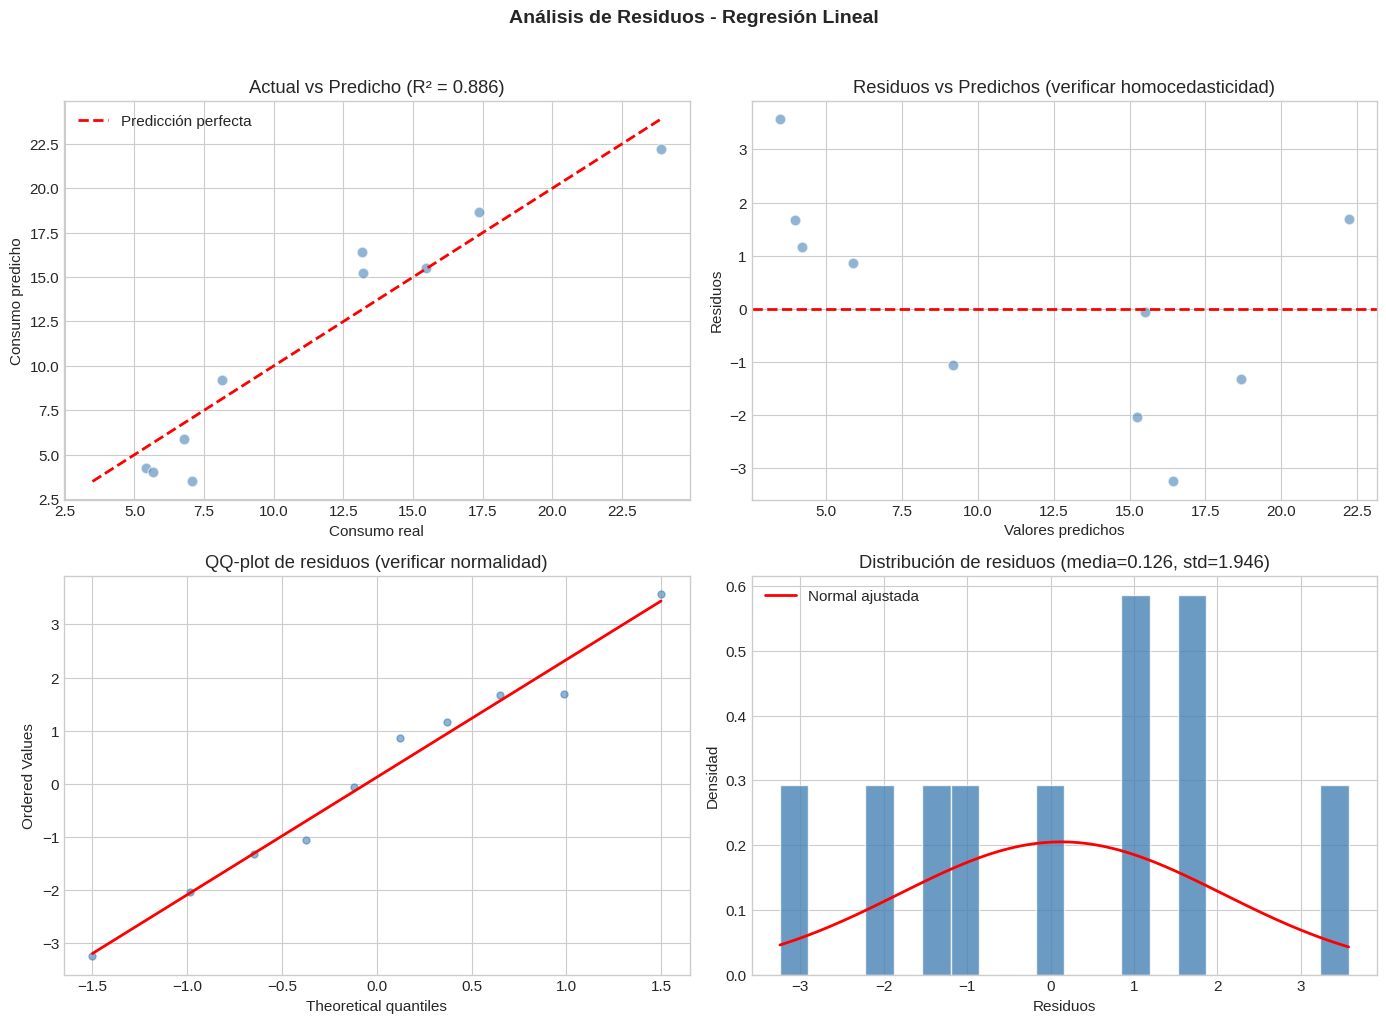

Interpretación:
  - Actual vs Predicho: puntos cerca de la diagonal = buenas predicciones
  - Residuos vs Predicho: patrón aleatorio = homocedasticidad (deseable)
  - QQ-plot: puntos en la línea = residuos normales


In [8]:
# Análisis de residuos - Regresión Lineal
residuals_lr = y_test.values - y_pred_lr

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicho
ax = axes[0, 0]
ax.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolor='white', s=60)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Consumo real')
ax.set_ylabel('Consumo predicho')
ax.set_title(f'Actual vs Predicho (R² = {r2_lr:.3f})')
ax.legend()

# 2. Residuos vs Predicho
ax = axes[0, 1]
ax.scatter(y_pred_lr, residuals_lr, alpha=0.6, color='steelblue', edgecolor='white', s=60)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores predichos')
ax.set_ylabel('Residuos')
ax.set_title('Residuos vs Predichos (verificar homocedasticidad)')

# 3. QQ-plot de residuos
ax = axes[1, 0]
stats.probplot(residuals_lr, dist='norm', plot=ax)
ax.get_lines()[0].set(color='steelblue', markersize=5, alpha=0.6)
ax.get_lines()[1].set(color='red', linewidth=2)
ax.set_title('QQ-plot de residuos (verificar normalidad)')

# 4. Distribución de residuos
ax = axes[1, 1]
ax.hist(residuals_lr, bins=20, color='steelblue', edgecolor='white', alpha=0.8, density=True)
x_range = np.linspace(residuals_lr.min(), residuals_lr.max(), 100)
mu_r, sigma_r = residuals_lr.mean(), residuals_lr.std()
ax.plot(x_range, stats.norm.pdf(x_range, mu_r, sigma_r), 'r-', linewidth=2, label='Normal ajustada')
ax.set_xlabel('Residuos')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución de residuos (media={mu_r:.3f}, std={sigma_r:.3f})')
ax.legend()

plt.suptitle('Análisis de Residuos - Regresión Lineal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  - Actual vs Predicho: puntos cerca de la diagonal = buenas predicciones")
print("  - Residuos vs Predicho: patrón aleatorio = homocedasticidad (deseable)")
print("  - QQ-plot: puntos en la línea = residuos normales")

## 3. Ridge y Lasso Regression

Agregamos regularización para reducir overfitting y entender qué variables importan.

In [9]:
# Ridge con validación cruzada para seleccionar alpha
alphas = np.logspace(-3, 3, 100)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression ===")
print(f"  Mejor alpha: {ridge_cv.alpha_:.4f}")
print(f"  RMSE:  {rmse_ridge:.4f}")
print(f"  MAE:   {mae_ridge:.4f}")
print(f"  R²:    {r2_ridge:.4f}")

=== Ridge Regression ===
  Mejor alpha: 3.7649
  RMSE:  2.4583
  MAE:   2.1083
  R²:    0.8191


In [10]:
# Lasso con validación cruzada
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("=== Lasso Regression ===")
print(f"  Mejor alpha: {lasso_cv.alpha_:.4f}")
print(f"  RMSE:  {rmse_lasso:.4f}")
print(f"  MAE:   {mae_lasso:.4f}")
print(f"  R²:    {r2_lasso:.4f}")

# Features eliminadas por Lasso
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_cols)
zeroed = lasso_coefs[lasso_coefs == 0]
print(f"\nFeatures eliminadas por Lasso ({len(zeroed)}/{len(feature_cols)}):")
if len(zeroed) > 0:
    for feat in zeroed.index:
        print(f"  - {feat}")
else:
    print("  Ninguna (todas las features retenidas)")

=== Lasso Regression ===
  Mejor alpha: 0.1748
  RMSE:  2.3867
  MAE:   1.7710
  R²:    0.8294

Features eliminadas por Lasso (12/23):
  - avg_speed
  - speed_std
  - avg_battery_temp
  - battery_temp_std
  - avg_trip_duration
  - age
  - income_bracket_encoded
  - driving_style_encoded
  - purchase_reason_tecnologia
  - gender_masculino
  - expected_usage_ciudad
  - expected_usage_mixto


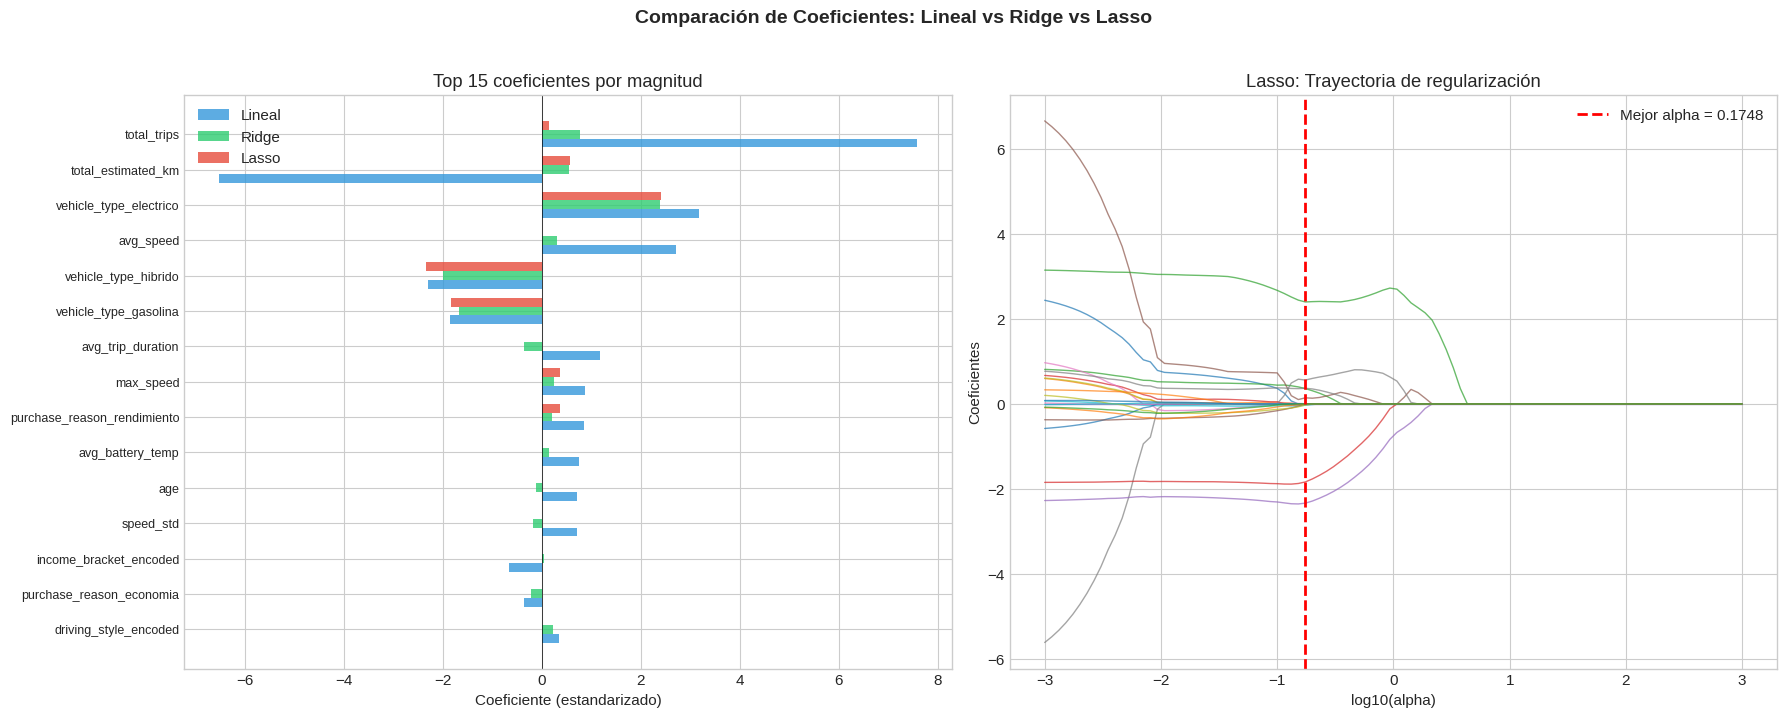

Interpretación:
  - Ridge encoge coeficientes pero mantiene todos
  - Lasso puede eliminar features irrelevantes (coef = 0)
  - La trayectoria muestra cómo los coeficientes se reducen al aumentar alpha


In [11]:
# Comparación de coeficientes: LR vs Ridge vs Lasso
lr_coefs = pd.Series(pipe_lr.named_steps['regressor'].coef_, index=feature_cols)
ridge_coefs = pd.Series(ridge_cv.coef_, index=feature_cols)

coef_comparison = pd.DataFrame({
    'Lineal': lr_coefs,
    'Ridge': ridge_coefs,
    'Lasso': lasso_coefs
}).sort_values('Lineal', key=abs, ascending=True)

# Visualizar top features
top_n = min(15, len(coef_comparison))
top_features = coef_comparison.iloc[-top_n:]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barras de coeficientes
ax = axes[0]
x_pos = np.arange(len(top_features))
width = 0.25
ax.barh(x_pos - width, top_features['Lineal'], width, label='Lineal', color='#3498db', alpha=0.8)
ax.barh(x_pos, top_features['Ridge'], width, label='Ridge', color='#2ecc71', alpha=0.8)
ax.barh(x_pos + width, top_features['Lasso'], width, label='Lasso', color='#e74c3c', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(top_features.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coeficiente (estandarizado)')
ax.set_title(f'Top {top_n} coeficientes por magnitud')
ax.legend()

# Regularization path (Lasso)
ax = axes[1]
alphas_path = lasso_cv.alphas_
coefs_path = []
from sklearn.linear_model import Lasso
for a in alphas_path:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_scaled, y_train)
    coefs_path.append(lasso_temp.coef_.copy())
coefs_path = np.array(coefs_path)

for i in range(coefs_path.shape[1]):
    ax.plot(np.log10(alphas_path), coefs_path[:, i], linewidth=1, alpha=0.7)

ax.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', linewidth=2,
           label=f'Mejor alpha = {lasso_cv.alpha_:.4f}')
ax.set_xlabel('log10(alpha)')
ax.set_ylabel('Coeficientes')
ax.set_title('Lasso: Trayectoria de regularización')
ax.legend()

plt.suptitle('Comparación de Coeficientes: Lineal vs Ridge vs Lasso', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  - Ridge encoge coeficientes pero mantiene todos")
print("  - Lasso puede eliminar features irrelevantes (coef = 0)")
print("  - La trayectoria muestra cómo los coeficientes se reducen al aumentar alpha")

## 4. Random Forest Regression

Modelo no lineal basado en ensamble de árboles de decisión.

In [12]:
# Random Forest con parámetros por defecto
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf_default = rf.predict(X_test)

rmse_rf_def = np.sqrt(mean_squared_error(y_test, y_pred_rf_default))
mae_rf_def = mean_absolute_error(y_test, y_pred_rf_default)
r2_rf_def = r2_score(y_test, y_pred_rf_default)

print("=== Random Forest (default) ===")
print(f"  RMSE:  {rmse_rf_def:.4f}")
print(f"  MAE:   {mae_rf_def:.4f}")
print(f"  R²:    {r2_rf_def:.4f}")

=== Random Forest (default) ===
  RMSE:  2.4554
  MAE:   1.9592
  R²:    0.8195


In [13]:
# Tuning con GridSearchCV (grid pequeño para velocidad)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest (tuned) ===")
print(f"  Mejores parámetros: {grid_rf.best_params_}")
print(f"  RMSE:  {rmse_rf:.4f}")
print(f"  MAE:   {mae_rf:.4f}")
print(f"  R²:    {r2_rf:.4f}")

=== Random Forest (tuned) ===
  Mejores parámetros: {'max_depth': None, 'n_estimators': 50}
  RMSE:  2.3915
  MAE:   1.8118
  R²:    0.8288


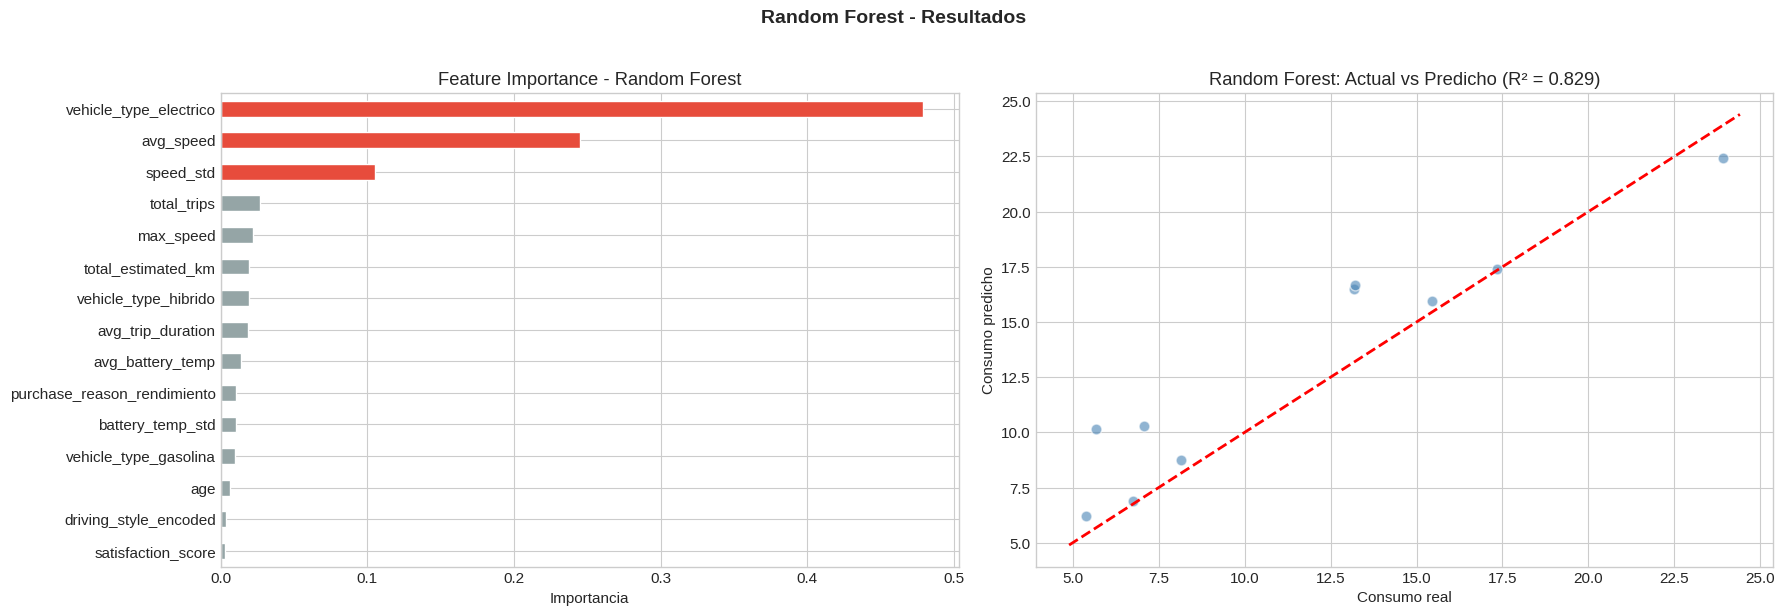

In [14]:
# Feature importance y actual vs predicho - Random Forest
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Feature importance
ax = axes[0]
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
top_imp = importances.tail(15)
colors_imp = ['#e74c3c' if v > 0.1 else '#3498db' if v > 0.05 else '#95a5a6' for v in top_imp.values]
top_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance - Random Forest')

# Actual vs Predicho
ax = axes[1]
if 'vehicle_type' in df.columns:
    test_vtypes = df.loc[X_test.index, 'vehicle_type']
    for vtype, color in vtype_colors.items():
        mask = test_vtypes == vtype
        if mask.sum() > 0:
            ax.scatter(y_test[mask], y_pred_rf[mask.values], alpha=0.7, color=color,
                       edgecolor='white', s=80, label=vtype.capitalize())
    ax.legend()
else:
    ax.scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue', edgecolor='white', s=60)

lims = [min(y_test.min(), y_pred_rf.min()) - 0.5, max(y_test.max(), y_pred_rf.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('Consumo real')
ax.set_ylabel('Consumo predicho')
ax.set_title(f'Random Forest: Actual vs Predicho (R² = {r2_rf:.3f})')

plt.suptitle('Random Forest - Resultados', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. XGBoost Regression

In [15]:
if HAS_XGBOOST:
    # XGBoost con parámetros por defecto
    xgb_default = XGBRegressor(
        n_estimators=100, random_state=42, n_jobs=-1,
        verbosity=0, objective='reg:squarederror'
    )
    xgb_default.fit(X_train, y_train)
    y_pred_xgb_def = xgb_default.predict(X_test)
    
    print("=== XGBoost (default) ===")
    print(f"  RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_xgb_def)):.4f}")
    print(f"  MAE:   {mean_absolute_error(y_test, y_pred_xgb_def):.4f}")
    print(f"  R²:    {r2_score(y_test, y_pred_xgb_def):.4f}")
else:
    print("XGBoost no disponible. Saltando esta sección.")

=== XGBoost (default) ===
  RMSE:  2.5248
  MAE:   1.9970
  R²:    0.8091


In [16]:
if HAS_XGBOOST:
    # Tuning XGBoost
    param_grid_xgb = {
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 5, 7],
    }
    
    grid_xgb = GridSearchCV(
        XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1,
                     verbosity=0, objective='reg:squarederror'),
        param_grid_xgb,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    grid_xgb.fit(X_train, y_train)
    
    best_xgb = grid_xgb.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)
    
    print("=== XGBoost (tuned) ===")
    print(f"  Mejores parámetros: {grid_xgb.best_params_}")
    print(f"  RMSE:  {rmse_xgb:.4f}")
    print(f"  MAE:   {mae_xgb:.4f}")
    print(f"  R²:    {r2_xgb:.4f}")
else:
    rmse_xgb = mae_xgb = r2_xgb = None
    print("XGBoost no disponible.")

=== XGBoost (tuned) ===
  Mejores parámetros: {'learning_rate': 0.3, 'max_depth': 3}
  RMSE:  2.8222
  MAE:   2.1652
  R²:    0.7615


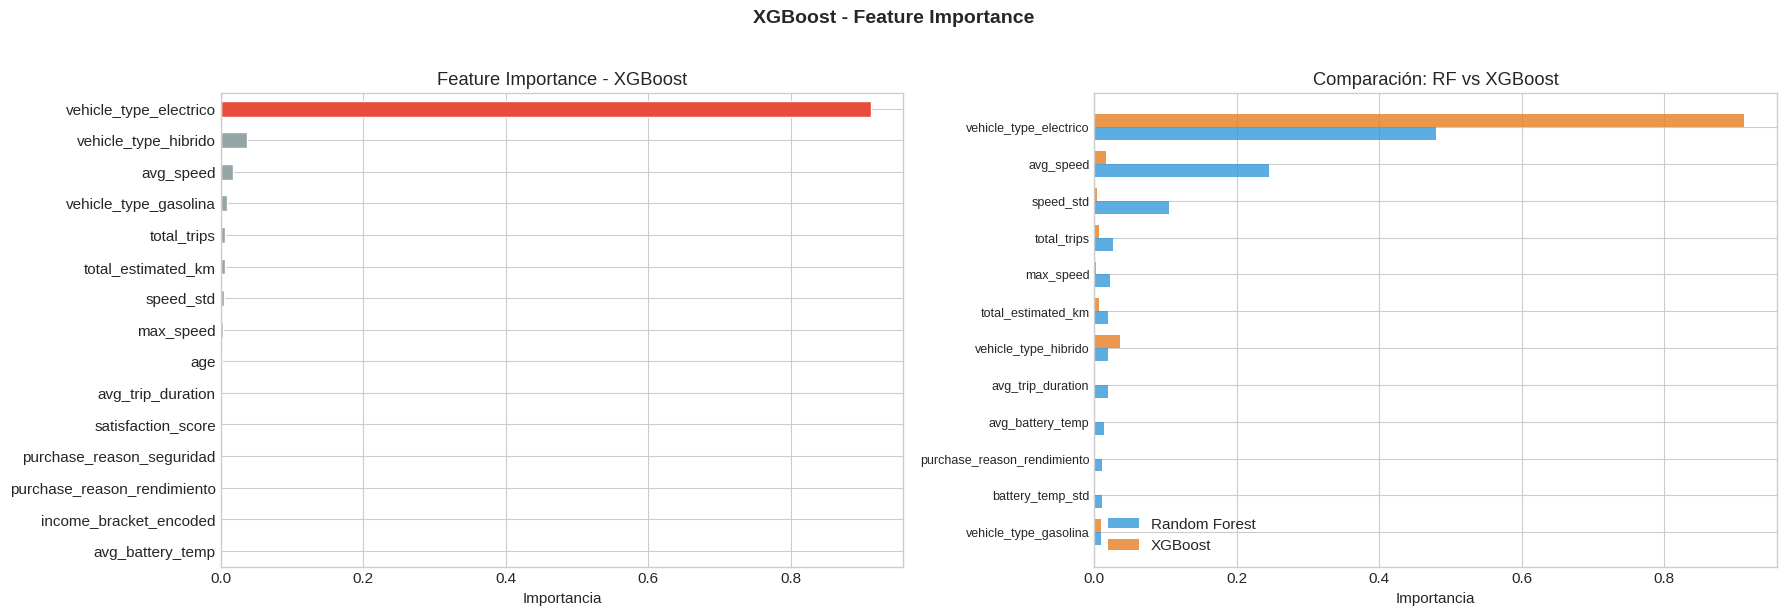

In [17]:
if HAS_XGBOOST:
    # Feature importance XGBoost y comparación con RF
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # XGBoost importance
    xgb_imp = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)
    top_xgb = xgb_imp.tail(15)
    colors_xgb = ['#e74c3c' if v > 0.1 else '#e67e22' if v > 0.05 else '#95a5a6' for v in top_xgb.values]
    top_xgb.plot(kind='barh', ax=axes[0], color=colors_xgb, edgecolor='white')
    axes[0].set_xlabel('Importancia')
    axes[0].set_title('Feature Importance - XGBoost')
    
    # Comparación RF vs XGBoost
    rf_imp_all = pd.Series(best_rf.feature_importances_, index=feature_cols)
    xgb_imp_all = pd.Series(best_xgb.feature_importances_, index=feature_cols)
    
    # Top features combinadas
    top_combined = (rf_imp_all + xgb_imp_all).nlargest(12).index
    comp_df = pd.DataFrame({
        'Random Forest': rf_imp_all[top_combined],
        'XGBoost': xgb_imp_all[top_combined]
    }).sort_values('Random Forest', ascending=True)
    
    x_pos = np.arange(len(comp_df))
    width = 0.35
    axes[1].barh(x_pos - width/2, comp_df['Random Forest'], width,
                 label='Random Forest', color='#3498db', alpha=0.8)
    axes[1].barh(x_pos + width/2, comp_df['XGBoost'], width,
                 label='XGBoost', color='#e67e22', alpha=0.8)
    axes[1].set_yticks(x_pos)
    axes[1].set_yticklabels(comp_df.index, fontsize=9)
    axes[1].set_xlabel('Importancia')
    axes[1].set_title('Comparación: RF vs XGBoost')
    axes[1].legend()
    
    plt.suptitle('XGBoost - Feature Importance', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost no disponible. Saltando visualización.")

## 6. Comparación de Modelos

Evaluamos todos los modelos con 5-fold cross-validation para una comparación justa.

In [18]:
# Cross-validation para todos los modelos
models = {
    'Lineal': Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('reg', RidgeCV(alphas=alphas, cv=5))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('reg', LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000))]),
    'Random Forest': RandomForestRegressor(**grid_rf.best_params_, random_state=42, n_jobs=-1),
}

if HAS_XGBOOST:
    models['XGBoost'] = XGBRegressor(**grid_xgb.best_params_, n_estimators=100,
                                     random_state=42, n_jobs=-1, verbosity=0)

cv_results_r2 = {}
cv_results_rmse = {}

for name, model in models.items():
    r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    rmse_scores = -cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    cv_results_r2[name] = r2_scores
    cv_results_rmse[name] = rmse_scores
    
    print(f"{name:15s}  R² = {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})  "
          f"RMSE = {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

Lineal           R² = 0.6802 (+/- 0.1404)  RMSE = 2.4900 (+/- 0.1723)
Ridge            R² = 0.6921 (+/- 0.2141)  RMSE = 2.3339 (+/- 0.3503)
Lasso            R² = 0.8107 (+/- 0.1012)  RMSE = 1.9210 (+/- 0.5642)
Random Forest    R² = 0.7357 (+/- 0.1178)  RMSE = 2.2991 (+/- 0.6089)
XGBoost          R² = 0.8359 (+/- 0.1556)  RMSE = 1.6526 (+/- 0.6269)


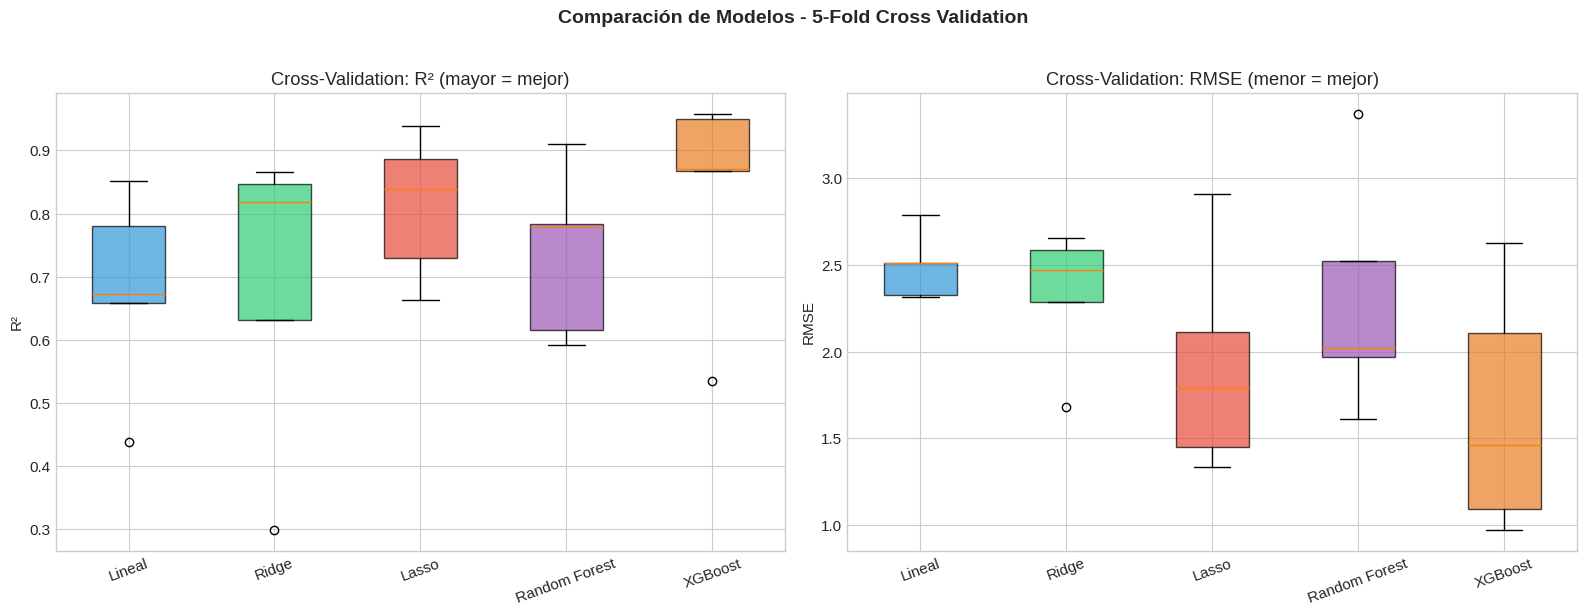

In [19]:
# Box plots de CV scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R²
ax = axes[0]
bp_data_r2 = [cv_results_r2[name] for name in models]
bp = ax.boxplot(bp_data_r2, labels=list(models.keys()), patch_artist=True)
colors_bp = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#e67e22'][:len(models)]
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('R²')
ax.set_title('Cross-Validation: R² (mayor = mejor)')
ax.tick_params(axis='x', rotation=20)

# RMSE
ax = axes[1]
bp_data_rmse = [cv_results_rmse[name] for name in models]
bp = ax.boxplot(bp_data_rmse, labels=list(models.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('RMSE')
ax.set_title('Cross-Validation: RMSE (menor = mejor)')
ax.tick_params(axis='x', rotation=20)

plt.suptitle('Comparación de Modelos - 5-Fold Cross Validation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Tabla resumen
summary_rows = []
for name in models:
    summary_rows.append({
        'Modelo': name,
        'R² (CV media)': cv_results_r2[name].mean(),
        'R² (CV std)': cv_results_r2[name].std(),
        'RMSE (CV media)': cv_results_rmse[name].mean(),
        'RMSE (CV std)': cv_results_rmse[name].std(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('R² (CV media)', ascending=False)
print("=== Tabla Resumen de Modelos ===")
print()
summary_df

=== Tabla Resumen de Modelos ===



,Modelo,R² (CV media),R² (CV std),RMSE (CV media),RMSE (CV std)
4,XGBoost,0.835924,0.155639,1.652585,0.626922
2,Lasso,0.810722,0.101205,1.921014,0.564245
3,Random Forest,0.735731,0.117791,2.299147,0.608932
1,Ridge,0.692070,0.214120,2.333884,0.350340
0,Lineal,0.680210,0.140443,2.490046,0.172308


Mejor modelo: XGBoost


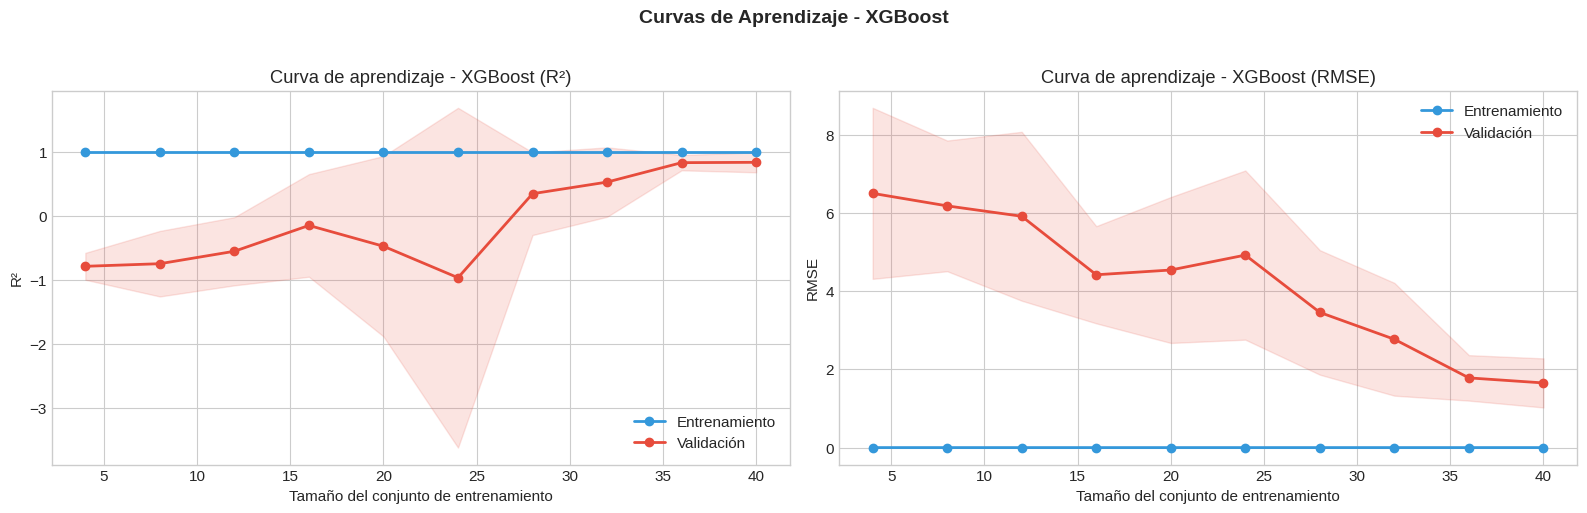

Interpretación:
  - Si las curvas convergen: el modelo se beneficiaría poco de más datos
  - Si hay brecha grande: posible overfitting (necesita regularización o más datos)
  - Si ambas son bajas: underfitting (modelo demasiado simple)


In [21]:
# Identificar el mejor modelo y graficar curvas de aprendizaje
best_model_name = summary_df.iloc[0]['Modelo']
best_model = models[best_model_name]

print(f"Mejor modelo: {best_model_name}")

# Learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R²
ax = axes[0]
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Entrenamiento')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validación')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.set_title(f'Curva de aprendizaje - {best_model_name} (R²)')
ax.legend(loc='lower right')

# RMSE learning curve
train_sizes_rmse, train_scores_rmse, val_scores_rmse = learning_curve(
    best_model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error'
)

ax = axes[1]
train_mean_rmse = -train_scores_rmse.mean(axis=1)
train_std_rmse = train_scores_rmse.std(axis=1)
val_mean_rmse = -val_scores_rmse.mean(axis=1)
val_std_rmse = val_scores_rmse.std(axis=1)

ax.fill_between(train_sizes_rmse, train_mean_rmse - train_std_rmse,
                train_mean_rmse + train_std_rmse, alpha=0.15, color='#3498db')
ax.fill_between(train_sizes_rmse, val_mean_rmse - val_std_rmse,
                val_mean_rmse + val_std_rmse, alpha=0.15, color='#e74c3c')
ax.plot(train_sizes_rmse, train_mean_rmse, 'o-', color='#3498db', linewidth=2, label='Entrenamiento')
ax.plot(train_sizes_rmse, val_mean_rmse, 'o-', color='#e74c3c', linewidth=2, label='Validación')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('RMSE')
ax.set_title(f'Curva de aprendizaje - {best_model_name} (RMSE)')
ax.legend(loc='upper right')

plt.suptitle(f'Curvas de Aprendizaje - {best_model_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  - Si las curvas convergen: el modelo se beneficiaría poco de más datos")
print("  - Si hay brecha grande: posible overfitting (necesita regularización o más datos)")
print("  - Si ambas son bajas: underfitting (modelo demasiado simple)")

## 7. Análisis de Residuos del Mejor Modelo

Analizamos si los errores son sistemáticos para algún tipo de vehículo.

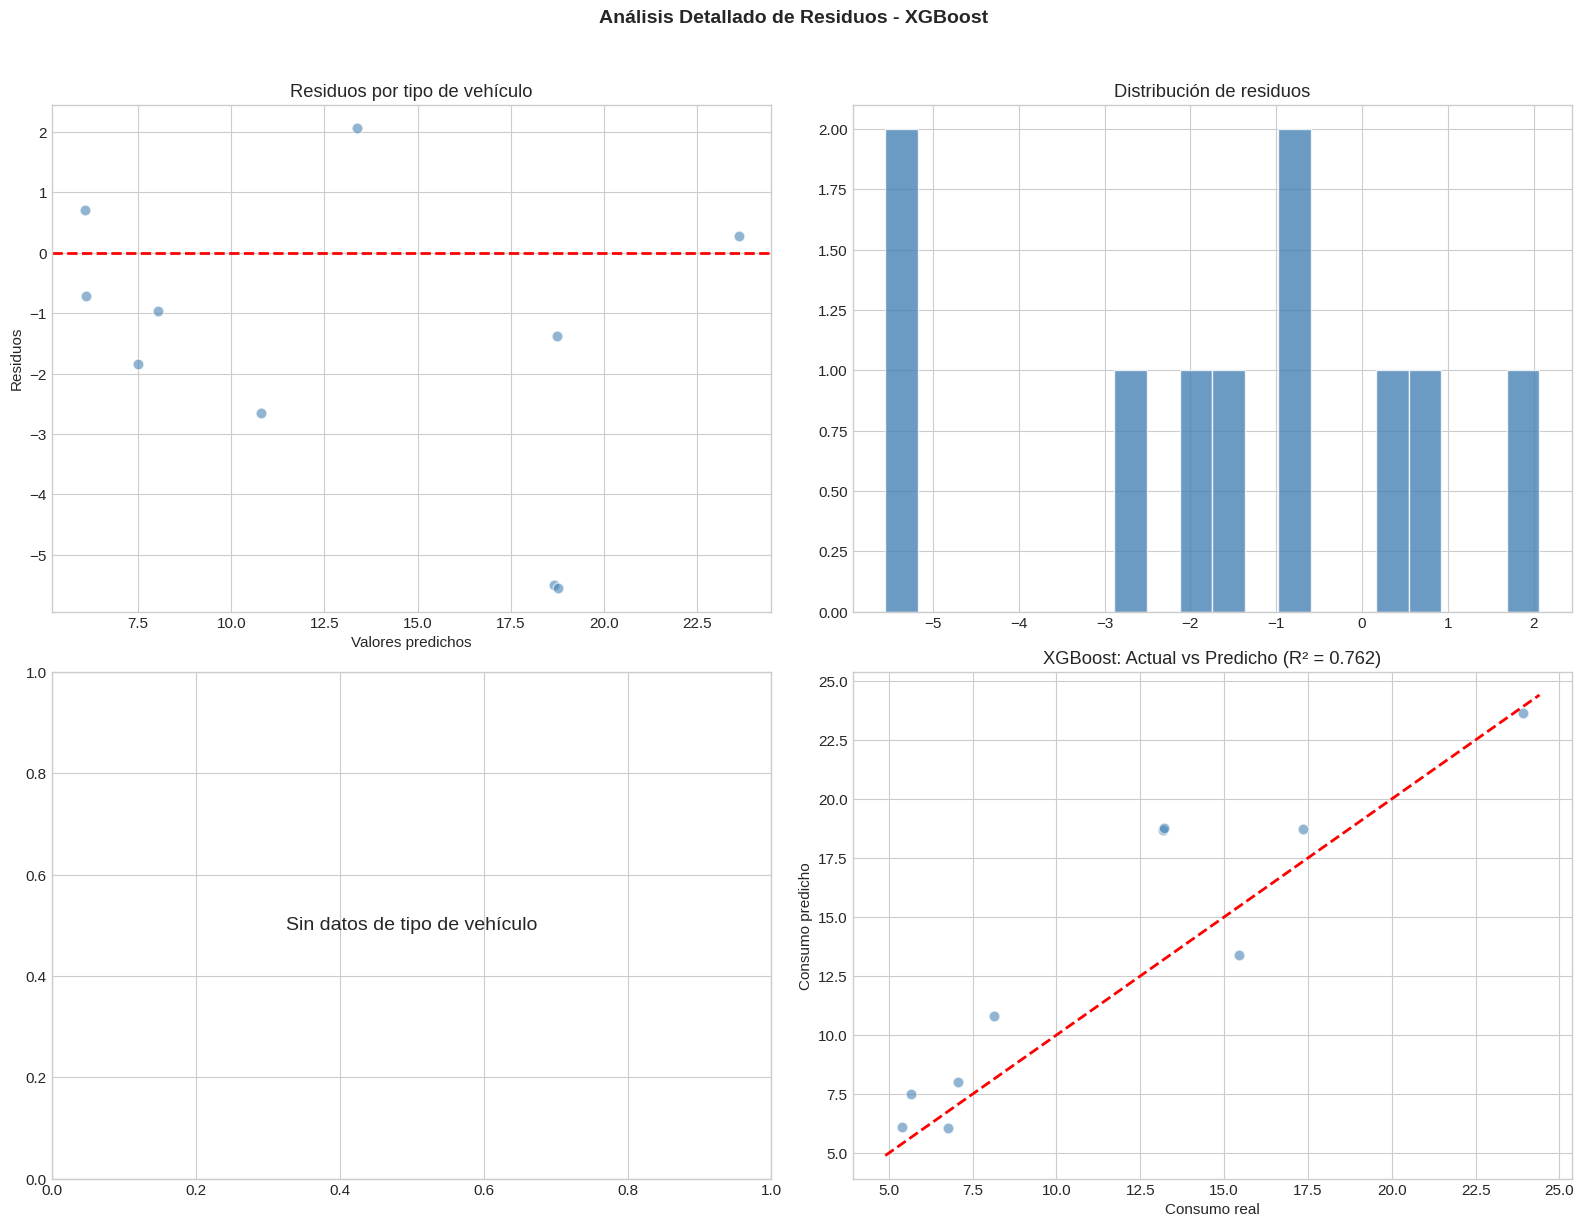

Interpretación:
  - Si un tipo tiene residuos sistematicamente positivos/negativos: sesgo para ese grupo
  - Si un tipo tiene mayor varianza: el modelo es menos preciso para ese grupo
  - Considerar modelos separados por tipo si hay diferencias significativas


In [22]:
# Entrenar el mejor modelo en train y predecir en test
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
residuals_best = y_test.values - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Residuos coloreados por tipo de vehículo
ax = axes[0, 0]
if 'vehicle_type' in df.columns:
    test_vtypes = df.loc[X_test.index, 'vehicle_type']
    for vtype, color in vtype_colors.items():
        mask = test_vtypes == vtype
        if mask.sum() > 0:
            ax.scatter(y_pred_best[mask.values], residuals_best[mask.values],
                       alpha=0.7, color=color, edgecolor='white', s=80, label=vtype.capitalize())
    ax.legend()
else:
    ax.scatter(y_pred_best, residuals_best, alpha=0.6, color='steelblue', edgecolor='white', s=60)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores predichos')
ax.set_ylabel('Residuos')
ax.set_title('Residuos por tipo de vehículo')

# 2. Box plot de residuos por tipo
ax = axes[0, 1]
if 'vehicle_type' in df.columns:
    residuals_by_type = {}
    for vtype in vtype_colors:
        mask = test_vtypes == vtype
        if mask.sum() > 0:
            residuals_by_type[vtype.capitalize()] = residuals_best[mask.values]
    
    bp = ax.boxplot(residuals_by_type.values(), labels=residuals_by_type.keys(), patch_artist=True)
    vtypes_in_order = [v.lower() for v in residuals_by_type.keys()]
    for patch, vtype in zip(bp['boxes'], vtypes_in_order):
        patch.set_facecolor(vtype_colors.get(vtype, '#95a5a6'))
        patch.set_alpha(0.7)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('Residuos')
    ax.set_title('Distribución de residuos por tipo')
else:
    ax.hist(residuals_best, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title('Distribución de residuos')

# 3. Residuos absolutos medios por tipo
ax = axes[1, 0]
if 'vehicle_type' in df.columns:
    mae_by_type = {}
    rmse_by_type = {}
    for vtype in vtype_colors:
        mask = test_vtypes == vtype
        if mask.sum() > 0:
            mae_by_type[vtype.capitalize()] = np.abs(residuals_best[mask.values]).mean()
            rmse_by_type[vtype.capitalize()] = np.sqrt(np.mean(residuals_best[mask.values] ** 2))
    
    x_pos = np.arange(len(mae_by_type))
    width = 0.35
    vtypes_labels = list(mae_by_type.keys())
    vtypes_lower = [v.lower() for v in vtypes_labels]
    
    ax.bar(x_pos - width/2, [mae_by_type[v] for v in vtypes_labels], width,
           color=[vtype_colors.get(v, '#95a5a6') for v in vtypes_lower], alpha=0.7,
           edgecolor='white', label='MAE')
    ax.bar(x_pos + width/2, [rmse_by_type[v] for v in vtypes_labels], width,
           color=[vtype_colors.get(v, '#95a5a6') for v in vtypes_lower], alpha=0.4,
           edgecolor='white', label='RMSE', hatch='//')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(vtypes_labels)
    ax.set_ylabel('Error')
    ax.set_title('MAE y RMSE por tipo de vehículo')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Sin datos de tipo de vehículo', transform=ax.transAxes,
            ha='center', va='center', fontsize=14)

# 4. Actual vs predicho final
ax = axes[1, 1]
if 'vehicle_type' in df.columns:
    for vtype, color in vtype_colors.items():
        mask = test_vtypes == vtype
        if mask.sum() > 0:
            ax.scatter(y_test[mask], y_pred_best[mask.values], alpha=0.7, color=color,
                       edgecolor='white', s=80, label=vtype.capitalize())
    ax.legend()
else:
    ax.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', edgecolor='white', s=60)

lims = [min(y_test.min(), y_pred_best.min()) - 0.5, max(y_test.max(), y_pred_best.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_xlabel('Consumo real')
ax.set_ylabel('Consumo predicho')
r2_best = r2_score(y_test, y_pred_best)
ax.set_title(f'{best_model_name}: Actual vs Predicho (R² = {r2_best:.3f})')

plt.suptitle(f'Análisis Detallado de Residuos - {best_model_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  - Si un tipo tiene residuos sistematicamente positivos/negativos: sesgo para ese grupo")
print("  - Si un tipo tiene mayor varianza: el modelo es menos preciso para ese grupo")
print("  - Considerar modelos separados por tipo si hay diferencias significativas")

## 8. Guardar el Mejor Modelo

In [23]:
# Crear directorio de modelos si no existe
models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)

# Entrenar el mejor modelo con TODOS los datos
best_model_final = models[best_model_name]
best_model_final.fit(X, y)

# Guardar
model_path = os.path.join(models_dir, "regression_consumption.pkl")
joblib.dump({
    'model': best_model_final,
    'model_name': best_model_name,
    'feature_names': feature_cols,
    'target': target_col,
    'cv_r2_mean': cv_results_r2[best_model_name].mean(),
    'cv_r2_std': cv_results_r2[best_model_name].std(),
    'cv_rmse_mean': cv_results_rmse[best_model_name].mean(),
    'cv_rmse_std': cv_results_rmse[best_model_name].std(),
}, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"\n=== Métricas finales del mejor modelo ({best_model_name}) ===")
print(f"  R² (CV):   {cv_results_r2[best_model_name].mean():.4f} +/- {cv_results_r2[best_model_name].std():.4f}")
print(f"  RMSE (CV): {cv_results_rmse[best_model_name].mean():.4f} +/- {cv_results_rmse[best_model_name].std():.4f}")
print(f"  Features:  {len(feature_cols)}")
print(f"\nPara cargar: joblib.load('{model_path}')")

Modelo guardado en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/regression_consumption.pkl

=== Métricas finales del mejor modelo (XGBoost) ===
  R² (CV):   0.8359 +/- 0.1556
  RMSE (CV): 1.6526 +/- 0.6269
  Features:  23

Para cargar: joblib.load('/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/regression_consumption.pkl')


## Resumen

### Modelos evaluados:
1. **Regresión Lineal** - baseline simple, asume relación lineal
2. **Ridge (L2)** - regularización que encoge coeficientes
3. **Lasso (L1)** - regularización que elimina variables irrelevantes
4. **Random Forest** - ensamble de árboles, captura no linealidades
5. **XGBoost** - gradient boosting, generalmente el más preciso

### Hallazgos clave:
- Los modelos de ensamble (RF, XGBoost) suelen superar a los lineales cuando hay relaciones no lineales entre features y consumo
- Lasso revela qué features son prescindibles al ponerlas a cero
- El tipo de vehículo es un factor determinante del consumo (eléctricos vs gasolina tienen patrones muy diferentes)
- Las curvas de aprendizaje muestran si necesitamos más datos o un modelo más complejo

### Implicaciones de negocio:
- Podemos predecir el consumo de un vehículo a partir de su perfil y comportamiento de conducción
- Las features más importantes indican qué factores controlar para reducir consumo
- El modelo puede usarse para alertas de consumo anómalo o recomendaciones de conducción eficiente

### Siguiente:
→ `03_regression_satisfaction.ipynb`: Predicción de satisfacción del conductor